# Semestrální projekt 1

In [1]:
.libPaths("C:/Users/kulka/OneDrive/Skola/BI-PRS/package") 

#install.packages("eurostat")
#install.packages("ggplot2")
#install.packages("vtable")
#install.packages('cowplot')
#install.packages('psych')
#install.packages('dplyr')
#install.packages('DescTools')
# install.packages('MESS') # gkgamma

# install.packages("ggpubr") # ggdensity
library(ggpubr)

#install.packages("lmtest") # dwtest
library(lmtest)

#install.packages("tseries") # jarque.bera.test
library("tseries")

#install.packages("polycor") # biserial.cor
library("polycor")

#install.packages("ltm") # biserial.cor
library("ltm")

library(MESS)
library(DescTools)
library(dplyr)
library(psych)  
library(kableExtra)
library(moments)
library(cowplot)
library(eurostat)
library(ggplot2)
library(vtable)
library(corrplot)
library(e1071)

options(width=300, repr.plot.width=15, repr.plot.height=10)

Loading required package: ggplot2

Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: MASS

Loading required package: msm


Attaching package: 'dplyr'


The following object is masked from 'package:MASS':

    select


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'psych'


The following objects are masked from 'package:DescTools':

    AUC, ICC, SD


The following object is masked from 'package:ltm':

    factor.scores


The following object is masked from 'package:polycor':

    polyserial


The following objects are masked from 'package:ggplot2':

    %+%, alpha



Attaching package: 'kableExtra'


The following object is mas

In [2]:
K = 11
L = 5 
((K+L)*47)%%(11)+1

[1] 5

### Popis dat

Budu pracovat s daty z "Policií evidovane zločiny podle NUTS3 regionů" pro Řecko.

Zajímat me budou:
- iccs
  - faktor, nominální
  - jaký tretsní čin byl spáchan
  - 7 kategorií
  - budou prepsané pro lepší čitelnost
- geo
  - faktor, nominální
  - v kterém regiónu byl zločin spáchan
  - 46 regionů pro NUTS3
  - 4 pro NUTS1
      - EL3 - 996 obyvatel / km2, 3 808 km2, 3 792 768 obyvatel
      - EL4 - &ensp;68 obyvatel / km2
      - EL5 - &ensp;58 obyvatel / km2
      - EL6 - &ensp;45 obyvatel / km2
   - NUTS3 regionu je trochu moc pro faktor, proto si data vemu z NUTS3 ale orientovat se budu podle NUTS1
- values
  - číselná hodnota
  - počet spáchaných zločinů pro danou kategorií a región
  - pro lepší reprezentaci hodnoty budov v jednotkách na 100,000 obyvatel

In [3]:
data = get_eurostat("crim_gen_reg")

#el_data <- data[data$geo %in% c('EL3', 'EL4', 'EL5', 'EL6'),]
el_data <- subset(data, grepl("^EL.{3}$", data$geo))
el_data <- el_data[el_data$unit=='P_HTHAB',] # na 100,000 obyvatel
#el_data <- el_data[el_data$unit=='NR',] # celkovy pocet
el_data <- el_data[el_data$TIME_PERIOD=='2021-01-01',]

el_data$freq = NULL
el_data$unit = NULL
el_data$TIME_PERIOD = NULL

el_data[el_data=="ICCS0101"]   <- "ZA" # umyslne zabiti
el_data[el_data=="ICCS02011"]  <- "NA" # napadeni
el_data[el_data=="ICCS0401"]   <- "LO" # loupez
el_data[el_data=="ICCS0501"]   <- "VL" # vloupani
el_data[el_data=="ICCS05012"]  <- "VS" # vloupani do soukromeho obytneho prostoru 
el_data[el_data=="ICCS0502"]   <- "KR" # kradez 
el_data[el_data=="ICCS050211"] <- "KV" # kradez vozidla

el_data$geo  <- as.factor(el_data$geo)
el_data$iccs <- as.factor(el_data$iccs)

el_data <- as.data.frame(el_data)

Table crim_gen_reg cached at C:\Users\kulka\AppData\Local\Temp\Rtmpk7moqM/eurostat/98af49bd352106a654325666eac609d0.rds



In [4]:
# region EL3 je v datech jenom jako jeden celek EL300, není rozdělen na 301 - 307
el_data[el_data$geo %in% c('EL300', 'EL301','EL302','EL303','EL304','EL305','EL306','EL307'),]
# proto některé funkce nebudou dobře fungovat pro EL3

# přechod kategorizace z NUTS3 na NUTS1
el_data$geo = strtrim(el_data$geo, 3) # ponechani jenom prvnich 3 znaku

,iccs,geo,values
,<fct>,<fct>,<dbl>
1,ZA,EL300,0.91
47,NA,EL300,93.56
93,LO,EL300,46.73
139,VL,EL300,162.79
185,VS,EL300,80.23
231,KR,EL300,948.82
277,KV,EL300,233.81


In [5]:
# konečný tvar dat
head(el_data)

,iccs,geo,values
,<fct>,<chr>,<dbl>
1,ZA,EL3,0.91
2,ZA,EL4,0.00
3,ZA,EL4,0.00
4,ZA,EL4,0.00
5,ZA,EL4,0.45
6,ZA,EL4,1.58


### Statisticke miry

In [6]:
summary(el_data)

 iccs        geo                values       
 KR:46   Length:322         Min.   :  0.000  
 KV:46   Class :character   1st Qu.:  4.407  
 LO:46   Mode  :character   Median : 35.255  
 NA:46                      Mean   : 64.671  
 VL:46                      3rd Qu.: 75.560  
 VS:46                      Max.   :976.320  
 ZA:46                                       

V datech mám dva faktory, typ spáchaného zločinu a region, takhle jsou data trochu promíchané a nemusím vidět důležité detaily. Proto pro jejich lepší pochopení si je rozdělím podle typu a regionu.

#### Podle regionu

![image](https://upload.wikimedia.org/wikipedia/commons/5/5a/NUTS_EL_2013.png)

In [7]:
describeBy(el_data[, c('values')], mat=TRUE, digits=2, group=el_data$geo)

,item,group1,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X11,1,EL3,1,7,223.84,328.66,93.56,223.84,102.64,0.91,948.82,947.91,1.44,0.43,124.22
X12,2,EL4,1,63,54.35,79.81,28.09,36.59,39.16,0.00,432.35,432.35,2.53,7.38,10.05
X13,3,EL5,1,126,56.45,107.66,30.98,34.95,39.68,0.00,976.32,976.32,5.53,40.84,9.59
X14,4,EL6,1,126,69.21,95.59,40.25,47.83,55.41,0.00,520.81,520.81,2.44,6.56,8.52


Data jsou stále trochu promíchaná, míchají se tady různý typy zločinu např. krádež (měsíce nebo roky) a zabití (roky až doživotí). To je dobře vidět na střední hodnotě, mediánu a směrodatné odchylce u EL3. Zároveň EL3 (Attiki) má nejvyšší kriminalitu, je to centrální region, nachází se tady hlavní město a má nejvyšší hustotu obyvatelstva v Řecku (996 obyvatel/km2, 14x větší než druhy nejvyšší). Proto není divu, že má taky nejvyšší kriminalitu. Jako jediný nemá nulové minimum. O dost níž (1/3 průměru z EL3) s druhou nejvyšší kriminalitou je EL6 (Kentriki Ellada). To je asi jeho umístěním, obklopuje většinu EL3 a je jediný region přímo s ním spojený. S trochu nižší kriminalitou jsou EL4 (Nisia Aigaiou, Kriti) a EL5 (Northern Greece) jsou téměř podobné až na hodně vysoký maximum u EL5 (vyšší než EL3) a špičatost. To by se asi taky dalo vysvětlit jeho umístěním, je to region který hraničí s Albánií, Severní Makedonií, Bulharskem a Tureckem.

Teď si regiony vykreslíme.

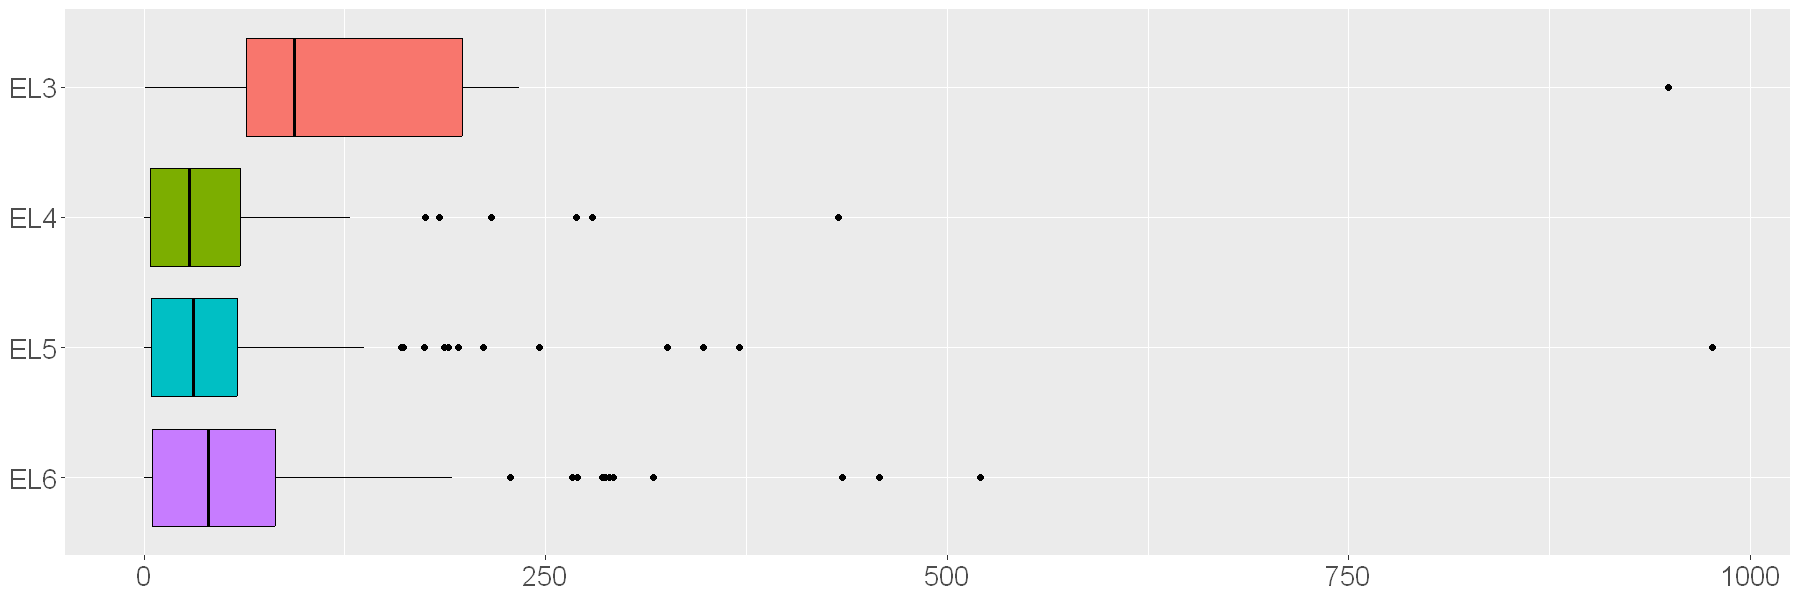

In [8]:
options(repr.plot.width = 15, repr.plot.height = 5)

ggplot(el_data, aes(x=values, y=geo, fill=geo)) +
        geom_boxplot(color="black", show.legend=F) +
        #geom_jitter(color="blue" , show.legend=F) +
        scale_y_discrete(limits=rev) + 
        theme(axis.title = element_blank(), text = element_text(size = 20))

Je tady moc outlierů, především u EL5 a EL3 máme 2 hodně velké outliery. O jaké zločiny se jedná?

In [9]:
el_data[el_data$values > 750, ]

,iccs,geo,values
,<fct>,<chr>,<dbl>
231,KR,EL3,948.82
247,KR,EL5,976.32


V obou případech se jednalo o krádež. A co ostatní outliery?

In [10]:
el3_data = subset(el_data, geo=='EL3', select=-geo)
el4_data = subset(el_data, geo=='EL4', select=-geo)
el5_data = subset(el_data, geo=='EL5', select=-geo)
el6_data = subset(el_data, geo=='EL6', select=-geo)

Q3 <- quantile(el3_data$values, .75)
IQR <- IQR(el3_data$values)
outliers <- subset(el3_data, el3_data$values > (Q3 + 1.5*IQR))

Q3 <- quantile(el4_data$values, .75)
IQR <- IQR(el4_data$values)
outliers <- rbind (outliers, subset(el4_data, el4_data$values > (Q3 + 1.5*IQR)))

Q3 <- quantile(el5_data$values, .75)
IQR <- IQR(el5_data$values)
outliers <- rbind (outliers, subset(el5_data, el5_data$values > (Q3 + 1.5*IQR)))

Q3 <- quantile(el6_data$values, .75)
IQR <- IQR(el6_data$values)
outliers <- rbind (outliers, subset(el6_data, el6_data$values > (Q3 + 1.5*IQR)))

count(outliers, iccs)

iccs,n
<fct>,<int>
KR,26
KV,2
VL,2


Téměř 87% outlierů jsou krádeže. Jejich hodně ale jedná se o ne tak závažný trestní čin ke kterému není zapotřebí násilí a proto není trestán tak přísně. To je nejspíš důvod proč tvoří tolik outlierů, zatím co horších trestních činů je méně a tvoří základ. Stejně je to tak pak asi s krádeži vozidla a vloupáním.

#### Podle trestního činu

In [11]:
el_data_byCrime = describeBy(el_data[, c('values')], mat="TRUE", digits=2, group=el_data$iccs)
el_data_byCrime[order(el_data_byCrime$median, decreasing = TRUE), ]

,item,group1,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X11,1,KR,1,46,227.70,200.28,179.30,195.31,147.05,21.79,976.32,954.53,2.13,5.24,29.53
X14,4,NA,1,46,60.34,30.02,53.88,56.84,21.18,16.34,174.40,158.06,1.49,2.78,4.43
X12,2,KV,1,46,68.23,54.52,51.63,60.91,44.04,0.00,246.24,246.24,1.49,2.32,8.04
X15,5,VL,1,46,61.87,63.58,37.97,51.41,32.77,0.00,347.96,347.96,2.34,6.98,9.37
X16,6,VS,1,46,28.00,26.10,19.22,24.53,20.12,0.00,114.35,114.35,1.25,1.07,3.85
X13,3,LO,1,46,5.84,8.63,3.20,4.09,3.51,0.00,46.73,46.73,3.17,10.98,1.27
X17,7,ZA,1,46,0.72,0.79,0.59,0.61,0.87,0.00,2.53,2.53,0.86,-0.30,0.12


Data jsem si setřídil, z předchozího pozorovaní předpokládám, že data nemají normální rozdělení, proto se budu orientovat spíše podle mediánu než průměru. 

Není překvapení, že nejčastějším spáchaným zločinem jsou krádeže. Zajímavá jsou ale napadení, které jsou na druhem místě, zatím co ostatní násilní činy jsou úplně dole. Jako jediný spolu s krádežemi nemají nulové minimum. Pak jsou tady krádeže vozidla, vloupáni a vloupáni do soukromého obytného prostoru, tvoři střed a nejsou nějak význačný. Na konci jsou loupeže a zabití. Loupeže mají nejvyšší šikmost a špičatost zatím co zabití nejnižší.

Data si znovu vsykrelíme.

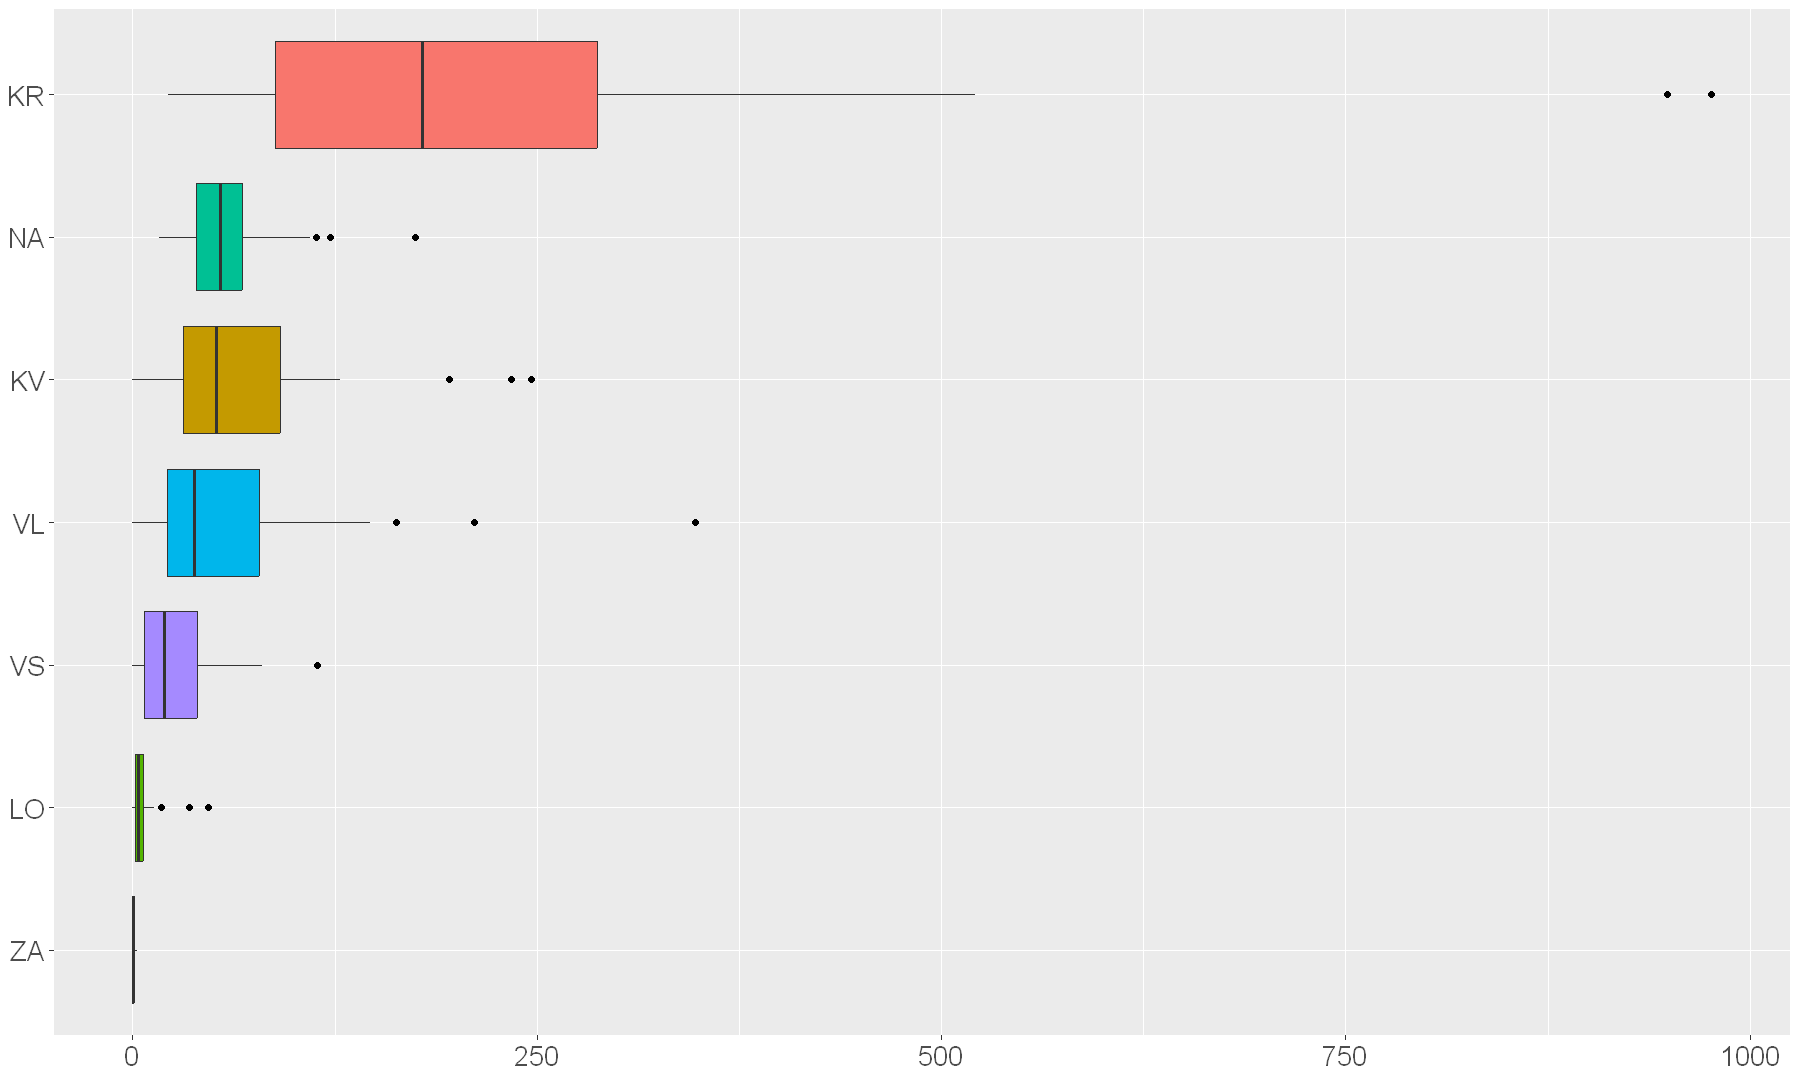

In [12]:
options(repr.plot.width = 15, repr.plot.height = 9)

ggplot(el_data, aes(x=values, y=iccs, fill=iccs)) +
    geom_boxplot(outlier.color="black", show.legend=F) +
    #geom_jitter(color="blue", show.legend=F) +
    scale_y_discrete(limits = c("ZA", "LO", "VS", "VL", "KV", "NA", "KR")) +
    theme(axis.title = element_blank(), text = element_text(size = 20))

### Kontingenční tabulka

Teď se podívám na data pomocí kontingenční tabulky, díky které budu moci zkoumat data podle obou faktoru zároveň.

In [13]:
mean_el_data = aggregate(el_data[, 3], list(el_data$iccs, el_data$geo), mean)

round(addmargins( prop.table(xtabs(formula=x ~ Group.2 + Group.1, data=mean_el_data)) ), 3)

,KR,KV,LO,NA,VL,VS,ZA,Sum
EL3,0.336,0.083,0.017,0.033,0.058,0.028,0.000,0.554
EL4,0.069,0.023,0.002,0.021,0.012,0.007,0.000,0.135
EL5,0.068,0.023,0.002,0.018,0.021,0.008,0.000,0.140
EL6,0.085,0.022,0.002,0.024,0.026,0.013,0.000,0.171
Sum,0.557,0.151,0.022,0.096,0.116,0.056,0.001,1.000


Víc, než půlka spáchaných zločinu jsou krádeže a víc, než půlka všech zločinu jsou spáchaná v EL3. V EL3 je zároveň spácháno 74 % loupeží. Je dobře vidět, že hodně zločinu je spáchaných v EL3 a ostatní regiony jsou na tom lépe. Jenom pro napadeni a zabiti jsou si všechny regiony trochu podobné, to je nejspíš důvod proč napadeni bylo tak vysoko v rozděleni podle trestního činů.

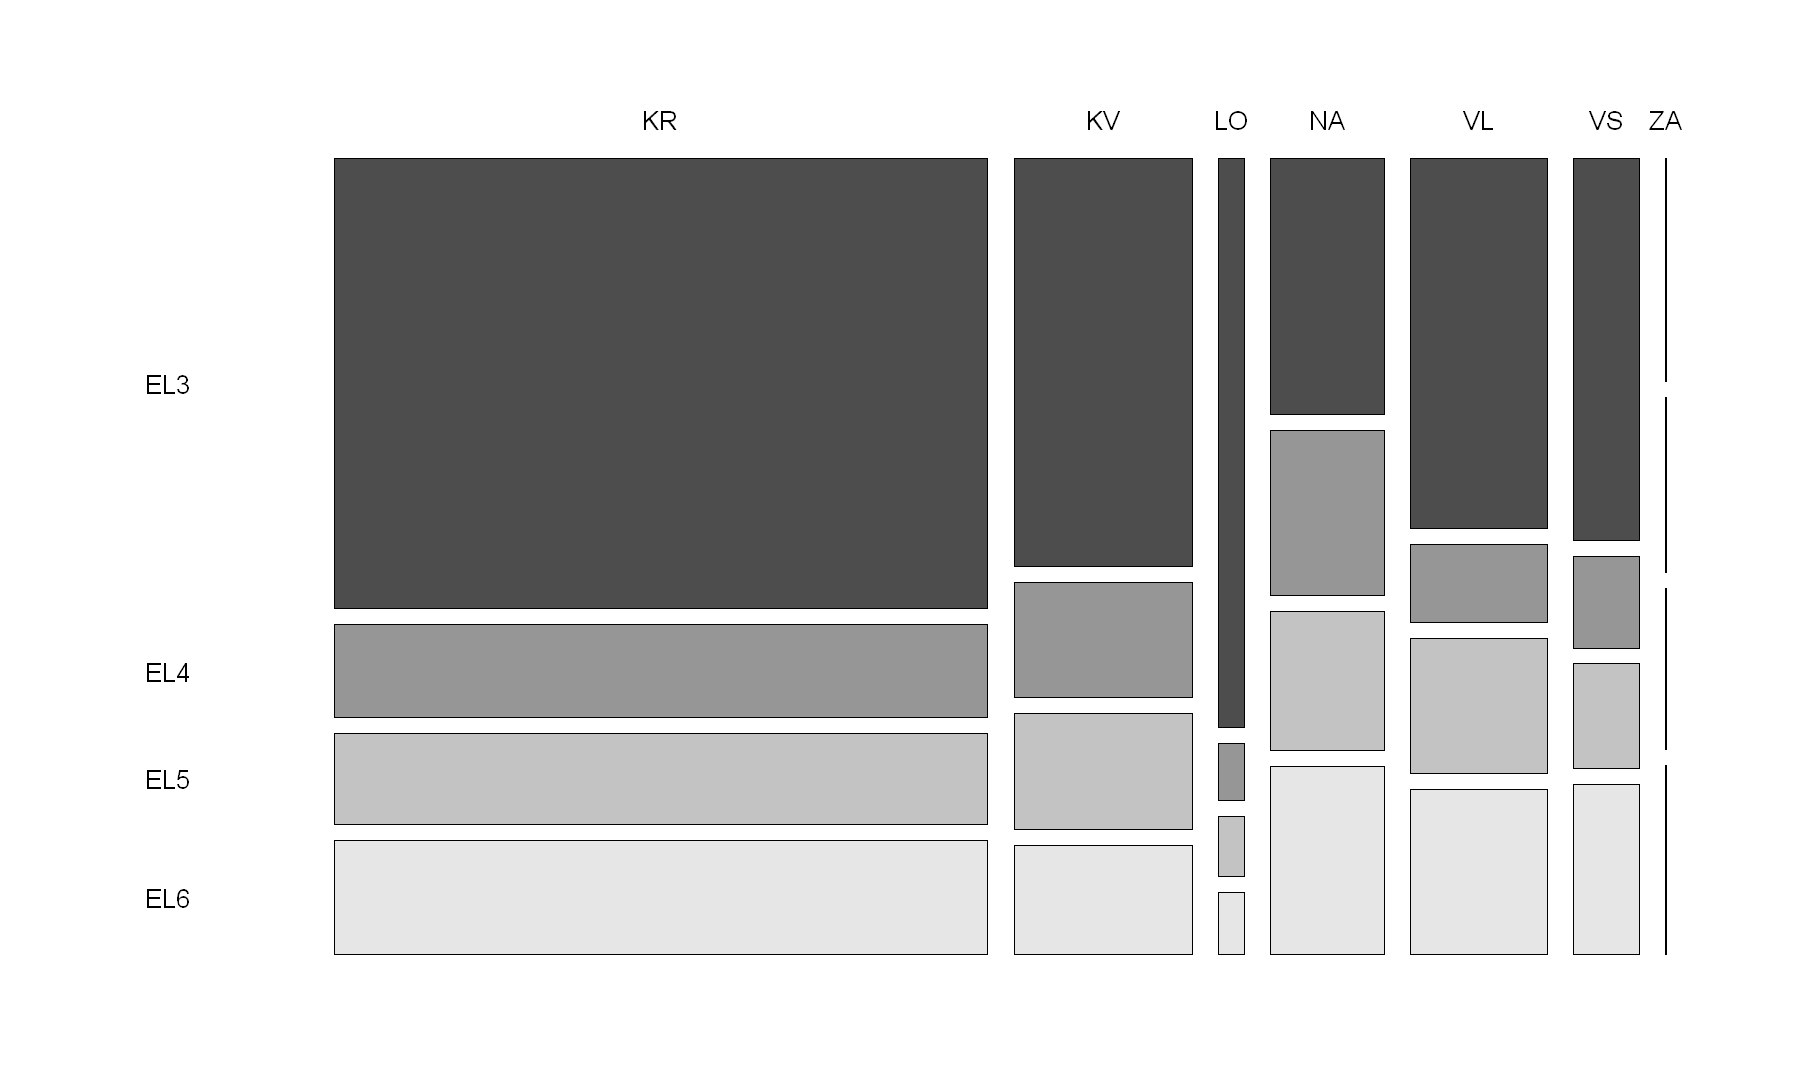

In [14]:
options(repr.plot.width = 15, repr.plot.height =9)

mosaicplot(main="", xlab="", ylab="", xtabs(formula=x ~ Group.1 + Group.2, data=mean_el_data), color=T, cex.axis = 1.3, las=1)

In [15]:
round(addmargins(xtabs(formula=x ~ Group.2 + Group.1, data=mean_el_data)),2)

,KR,KV,LO,NA,VL,VS,ZA,Sum
EL3,948.82,233.81,46.73,93.56,162.79,80.23,0.91,1566.85
EL4,195.81,65.59,4.70,60.05,34.39,19.17,0.71,380.42
EL5,191.64,66.19,4.93,50.46,59.45,21.83,0.65,395.15
EL6,239.65,62.39,5.04,68.54,72.42,35.68,0.77,484.48
Sum,1575.93,427.97,61.40,272.60,329.05,156.91,3.04,2826.90


Data nemám moc hezká, proto by mi většina testu nemusela fungovat správné:
- Pearsonov test nezávislosti - malo dat pro test, musí byt aspoň 5+ v každý bunce
- Fisheruv test  jen pro malo dat
- Barnard test - jen pro 2x2
- Kendall rank - nemají normální rozděleni, nejsou ordinální
- McNemaruv test - jen pro 2x2
- Goodman Kruskal gamma - data nejsou ordinální


Ale mužu udelat Cramerovo V.
- $H_0$: mezi regionem a typem zločinu není asociativita
- $H_A$: neplatí $H_0$

In [16]:
round(CramerV(xtabs(formula=x ~ Group.2 + Group.1, data=mean_el_data), conf.level=0.95), 3)

Cramer V   lwr.ci   upr.ci 
   0.107    0.075    0.119

Cramerovo V mi vyšlo nižší než horní hranice, nulovú hypotézu proto nezamítám. Takže mezi faktory není asociativita neboť je statisticky nevýznamná na mnou zvolenou hladinu významnosti. Jinak řečeno, když vím v kterém region byl spáchán zločin nedokážu s jistotou určit o jaký typ zločinu se jedna, a nebo naopak.

### Testy

#### Normalita
V některých rozborech jsem přepokládal, že data nemají normalitu, proto si to teď ověřím. Použiju Jarque-Berúv test místo Shapirův-Wilkův test, je slabší ale v datech se mi opakuje nula u ZA a to muže ovlivnit Shapirův-Wilkův test.
- $H_0$: data jsou normálně rozdelená
- $H_A$: data nejsou normálně rozdelená

In [17]:
jarque.bera.test(el_data$values)


	Jarque Bera Test

data:  el_data$values
X-squared = 12341, df = 2, p-value < 2.2e-16


P-hodnota je velice malá, tudiž na 0.05 hladine významnosti zamýtam nulovú hypotézu. Data nejsou normálně rozdělená a je to dobře vidět i na grafu.


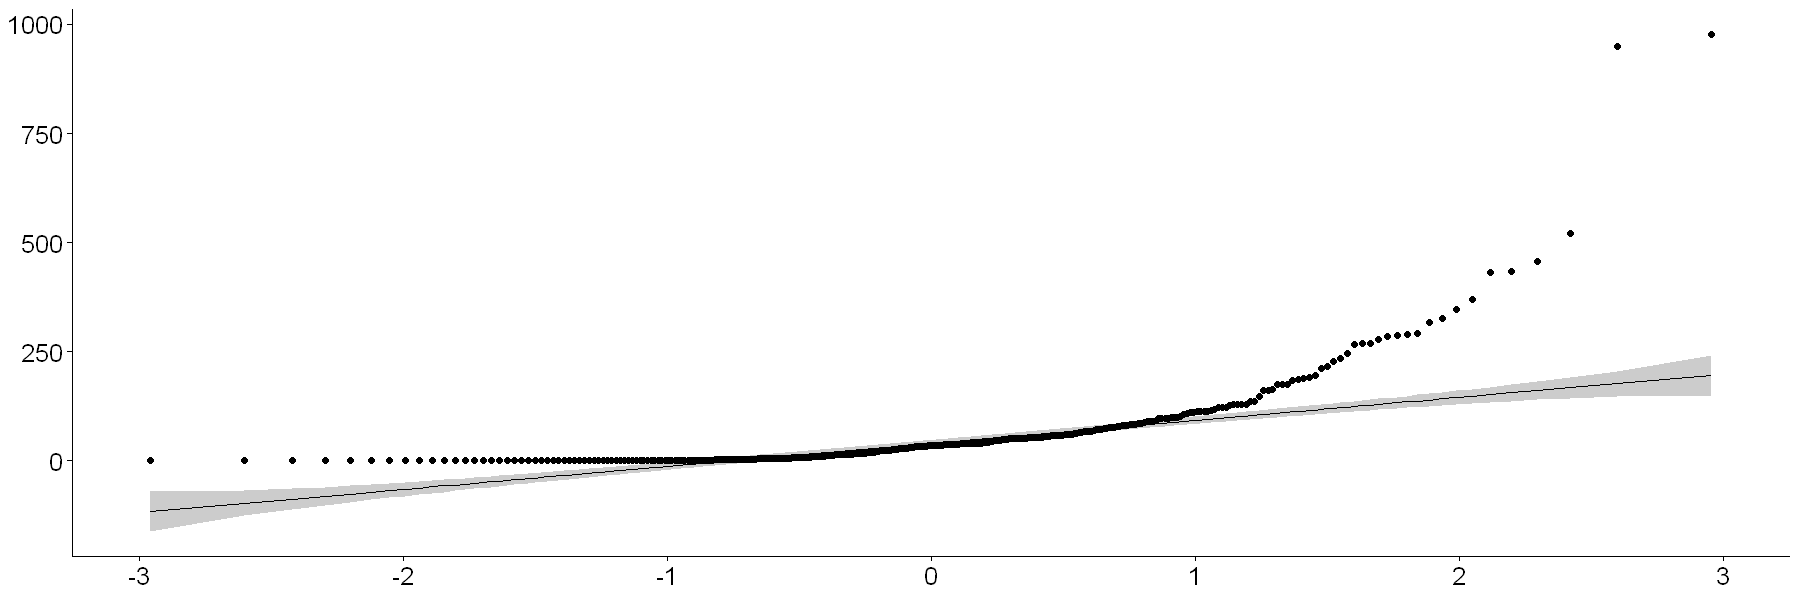

In [18]:
options(repr.plot.width = 15, repr.plot.height = 5)

ggqqplot( el_data$values ) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

U rozboru podle trestního činu jsem si všiml že zabiti mají nízkou šikmost a špičatost, oproti ostatním, co by mohlo poukazovat na normálně rozdělení. Tak si to taky otestuji.
- $H_0$: data jsou normálně rozdelená
- $H_A$: data nejsou normálně rozdelená


	Jarque Bera Test

data:  el_data_ZA$values
X-squared = 6.0525, df = 2, p-value = 0.0485


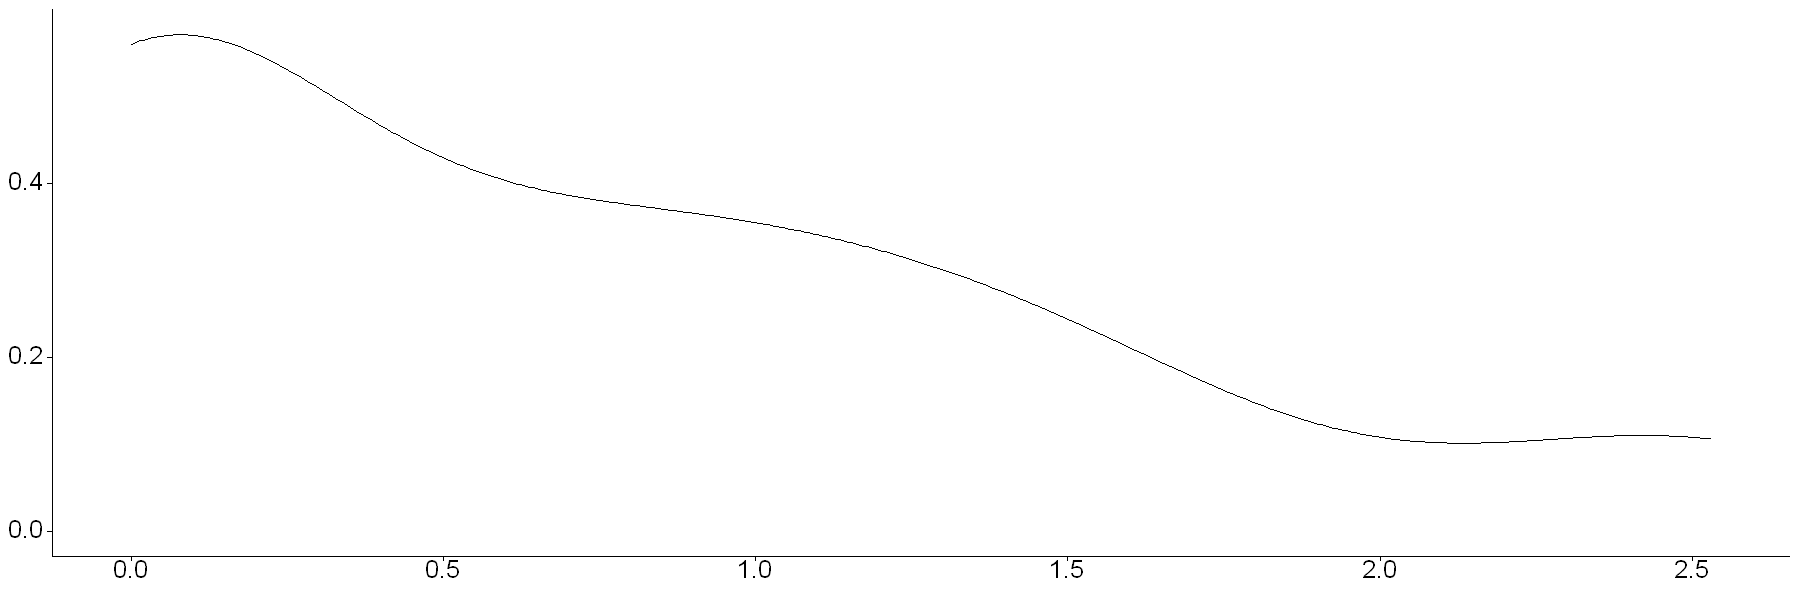

In [19]:
options(repr.plot.width = 15, repr.plot.height = 5)

el_data_ZA = el_data[el_data$iccs == "ZA", ]

ggdensity( el_data_ZA$values ) +
        theme(axis.title = element_blank(), text = element_text(size = 15))

jarque.bera.test(el_data_ZA$values)

A znovu ne, p-hodnota je menši než 0.05 a proto musím nulovú hypotézu zamítnout v prospech alternatívy. Tudíž ani data pro zabití nemají normálni rozdelení.

#### Porovnáni se sousedem
Podívám se, jestli Bulharsko má stejné rozděleni dat jako Řecko. Použiju Kolmogorovovův-Smirnovův dvou výběrový test, protože nepřepokládám normálně rozdělení a možnost posunutí.
- $H_0$: $F=G$
- $H_A$: $F\ne G$

In [20]:
bg_data <- subset(data, grepl("^BG.{3}$", data$geo))
bg_data <- bg_data[bg_data$unit=='P_HTHAB',]
bg_data <- bg_data[bg_data$TIME_PERIOD=='2021-01-01',]

el = el_data[2:3]
bg = bg_data[c(4,6)]

el$geo = strtrim(el_data$geo, 2)
bg$geo = strtrim(bg_data$geo, 2)

el_bg = rbind(el,bg)

Warning message in ks.test.default(el_data$values, bg_data$values):
"p-value will be approximate in the presence of ties"



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  el_data$values and bg_data$values
D = 0.11979, p-value = 0.06061
alternative hypothesis: two-sided


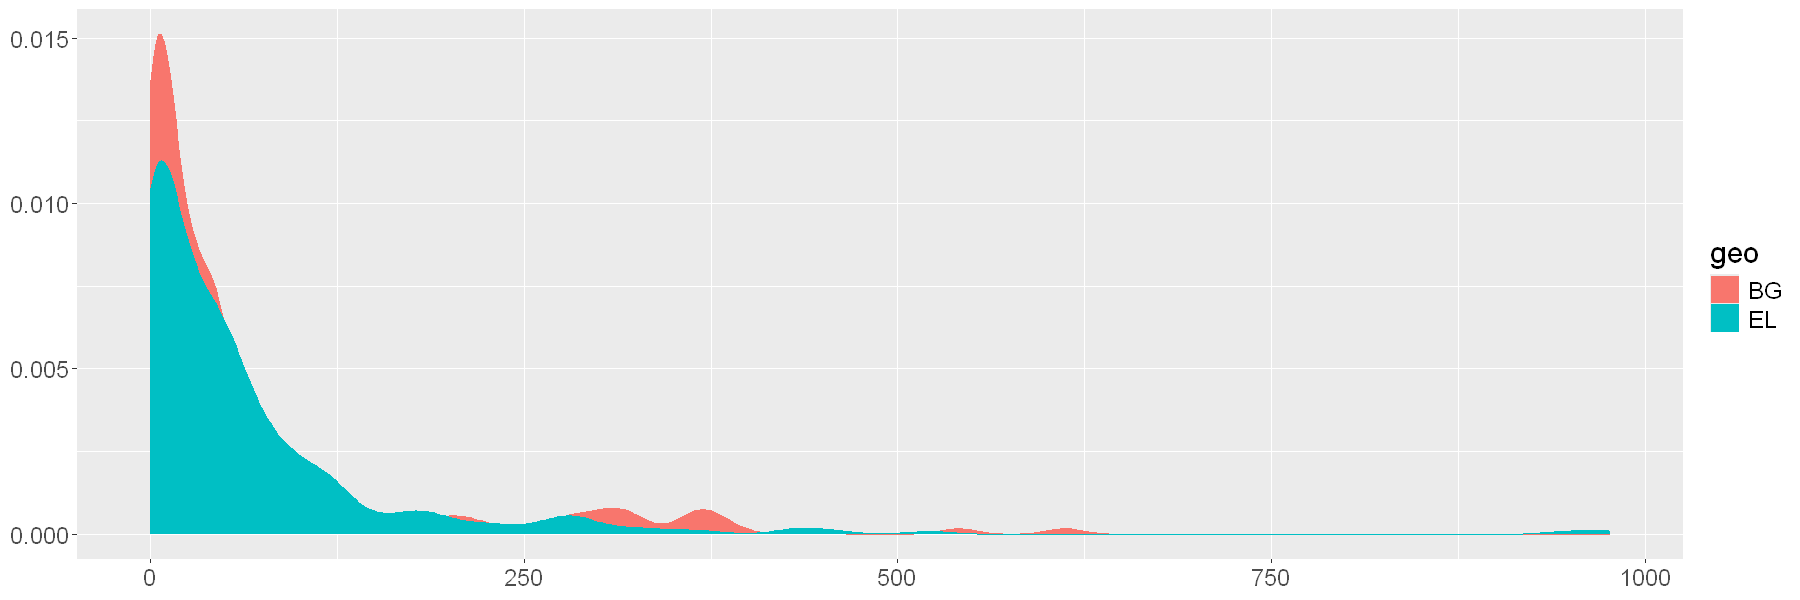

In [21]:
ggplot(el_bg, aes(x=values, group=geo, col=geo, fill=geo)) +
    geom_density() +
    theme(axis.title = element_blank(), text = element_text(size = 18))

ks.test(el_data$values, bg_data$values)

P-hodnota je vetší než 0.05 a proto hypotézu nezamítám. Závěru je, že neexistuje dostatek důkazů, které by naznačovaly, že data mají různé rozdělení. 

#### Minulé roky
Porovnám mediány z posledního a prvního roku dat. Použiju dvou výběrový Wilcoxonův test protože data nemají normální rozděleni.
- $H_0$: pro medián plati: 2008 = 2021
- $H_A$: pro medián plati: 2008 > 2021

In [22]:
el_08 <- subset(data, grepl("^EL.{3}$", data$geo))
el_08 <- el_08[el_08$unit=='P_HTHAB',]
el_08 <- el_08[el_08$TIME_PERIOD=='2008-01-01',]

In [23]:
wilcox.test(el_08$values, el_data$values, alternative='greater')


	Wilcoxon rank sum test with continuity correction

data:  el_08$values and el_data$values
W = 48657, p-value = 0.02252
alternative hypothesis: true location shift is greater than 0


Nulová hypotéza se zamítá ve prospech alternatívy. Mám teda statisticky významný důkaz, že medián z roku 2008 by mohl byt vetší než z roku 2021.

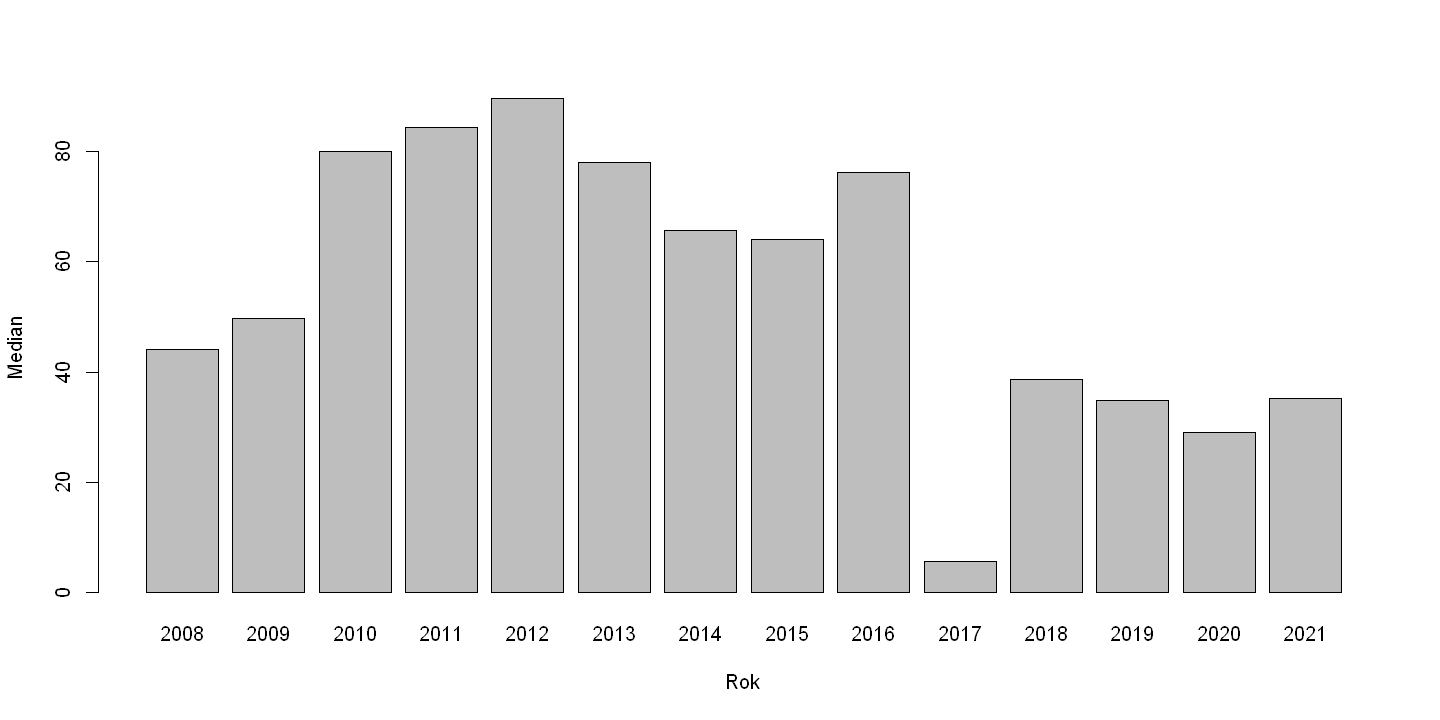

In [24]:
options(repr.plot.width = 12, repr.plot.height = 6)

el_years <- subset(data, grepl("^EL.{3}$", data$geo))
el_years <- el_years[el_years$unit=='P_HTHAB',]
el_years$TIME_PERIOD = strtrim(el_years$TIME_PERIOD, 4)
el_years <- as.data.frame(el_years)

med_years = tapply(el_years$values, el_years$TIME_PERIOD, median)
barplot(med_years, xlab = "Rok", ylab = "Median")